# AI Studio 2025 - main notebook

You should have a file from PPFA named "credential.json". Put in the directory where you're running this project, and then run the next cell of this document!

Note that unless you get instructions from your Challenge Advisors, you shouldn't ever need to change the code in this next cell.

In [1]:
from google.oauth2 import service_account
import pandas_gbq
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.tree import plot_tree
from sklearn.metrics import ConfusionMatrixDisplay
import re
import unicodedata
import nltk
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer, PorterStemmer
from spellchecker import SpellChecker
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    accuracy_score,
    log_loss,
    recall_score,
    f1_score
)

In [2]:
credentials = service_account.Credentials.from_service_account_file(
    "./credential.json",
    scopes=["https://www.googleapis.com/auth/cloud-platform"],
)
pandas_gbq.context.credentials = credentials
pandas_gbq.context.project = "roo-ds"

df = pandas_gbq.read_gbq("SELECT * FROM roo-ds.ai_studio_2025.labeled_conversations")
df

Downloading: 100%|██████████|


,Genesys_interaction_id,Full_conversation,First_prompt,First_response,Interaction_contains_PII,First_label,Flag_label_for_review,Comment,Provided_prompt,Provided_prompt_autocalculated,Labeller,Reviewer_suggested_label,Reviewer,Reviewer_comment,Ease_of_use,Helpfulness,Understanding,Recommendation
0,1291f093-33bb-48b3-824b-59a10b77ae31,"[{""text"":""Hey there, I'm Roo! You can ask me q...",how long does it take to ejaculate when i mast...,\n\nEjaculation (aka cumming) typically starts...,False,FP,True,None,False,False,Karen,FP,Michael,None,<NA>,<NA>,<NA>,<NA>
1,fbf1bebc-8f51-43a9-8554-58fe3a63cfaf,"[{""text"":""Hey there, I'm Roo! You can ask me q...",What types of kisse are there and how to do it...,"\n\nI'm a robot, so I can't really explain the...",False,TP,False,None,False,False,Karen,None,None,None,<NA>,<NA>,<NA>,<NA>
2,52e96081-9f3a-411d-b7c5-ff5f9f6028e2,"[{""text"":""Hey there, I'm Roo! You can ask me q...",I’m spotting pink,\n\nSpotting is completely normal and can happ...,False,TP,False,None,False,False,Karen,None,None,None,<NA>,<NA>,<NA>,<NA>
3,55f178cf-8b7b-451d-98a6-0d38097c7b16,"[{""text"":""Hey there, I'm Roo! You can ask me q...",I am having brown discharge but idk if it’s sp...,\n\nSpotting is completely normal and can happ...,False,FP,True,None,False,False,Karen,FP,Michael,None,<NA>,<NA>,<NA>,<NA>
4,748f6a7f-38b0-414c-842c-da27ab370360,"[{""text"":""Hey there, I'm Roo! You can ask me q...",I had my regular cycle for a week and now have...,\n\nSpotting is completely normal and can happ...,False,TP,False,None,False,False,Karen,None,None,None,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2081,caa41186-0787-4cd6-bb6a-8494b678ecb7,"[{""text"":""Hey there, I'm Roo! You can ask me q...",Does Planned Parenthood offer pap smears?,Yes. Planned Parenthood health centers offer P...,False,TP,False,None,False,False,Karen,None,None,None,<NA>,<NA>,<NA>,<NA>
2082,caa41186-0787-4cd6-bb6a-8494b678ecb7,"[{""text"":""Hey there, I'm Roo! You can ask me q...",Does Planned Parenthood offer pap smears?,Yes. Planned Parenthood health centers offer P...,False,TP,False,None,False,False,Karen,None,None,None,<NA>,<NA>,<NA>,<NA>
2083,ddf7406f-e3ab-4896-b4cf-6a71f20c446d,"[{""text"":""Hey there, I'm Roo! You can ask me q...",Does planned parenthood Eugene offer walk in s...,Yes. Planned Parenthood health centers offer P...,False,TP,True,In general we offer it but they talk about spe...,False,False,Karen,None,None,None,<NA>,<NA>,<NA>,<NA>
2084,ddf7406f-e3ab-4896-b4cf-6a71f20c446d,"[{""text"":""Hey there, I'm Roo! You can ask me q...",Does planned parenthood Eugene offer walk in s...,Yes. Planned Parenthood health centers offer P...,False,TP,True,In general we offer it but they talk about spe...,False,False,Karen,None,None,None,<NA>,<NA>,<NA>,<NA>


Now you have a pandas DataFrame called `df` and you can use that in the rest of this project!

In [3]:
df.shape

(2086, 18)

In [4]:
#1)Analyzing the data and making bar graph

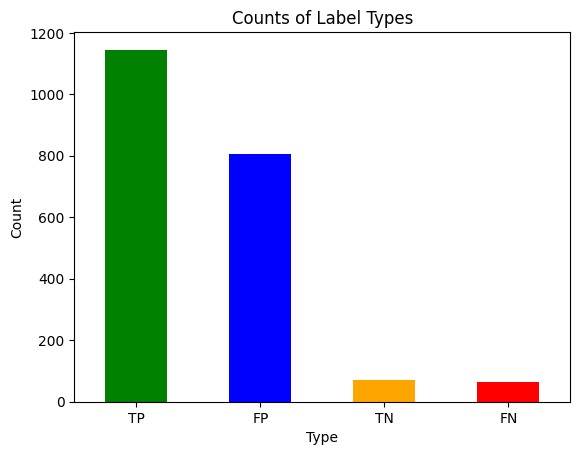

In [5]:
counts = df["First_label"].value_counts() 
counts


counts.plot(kind="bar", color=["green", "blue", "orange", "red"])
plt.title("Counts of Label Types")
plt.xlabel("Type")
plt.ylabel("Count")
plt.xticks(rotation=0)  # Keep x-axis labels horizontal
plt.show()


In [6]:
###Analysis: We need more augmented True Negative and False Negative Data to make our data more robust

In [7]:
#2)Augmentation of TN and FN data

In [8]:
# --- ALL Ryan / Ogechika / Zerlyne / Emma / Camila FN / TN / FP  examples (Complete) ---
new_examples = pd.DataFrame([
    # --- FN examples ---
    {"First_prompt": "Do you have offices in Chicago?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "FN"},
    {"First_prompt": "Do you have a location in Hawaii?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "FN"},
    {"First_prompt": "I think I might be pregnant, what should I do?",
     "First_response": "I’m a bot so I can’t answer certain questions. You can always contact your nearest Planned Parenthood health center to make an appointment about your health concerns. You can also find answers to common questions on our blog. Want to learn more about costs?",
     "First_label": "FN"},
    {"First_prompt": "Where can I see my medical records?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "FN"},
    {"First_prompt": "I feel really unsafe with my partner, what should I do?",
     "First_response": "I'm just a bot, but I do know it's not OK for someone to pressure you to have sex. I think a real person can give you better advice in this situation. Check out Love is Respect — they have really helpful info about how to communicate your needs in a relationship.",
     "First_label": "FN"},
    {"First_prompt": "I’m 15 and I think I might be pregnant.",
     "First_response": "I’m a bot so I can’t answer certain questions. You can always contact your nearest Planned Parenthood health center to make an appointment about your health concerns. You can also find answers to common questions on our blog.",
     "First_label": "FN"},
    {"First_prompt": "What is Nip-nops?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "FN"},
    {"First_prompt": "I go to Florida for vacations, which protection should I use?",
     "First_response": "I’m a bot so I can’t answer certain questions. You can always contact your nearest Planned Parenthood health center about any health concerns.",
     "First_label": "FN"},
    {"First_prompt": "I have a weird bump on my armpit, what is that?",
     "First_response": "I’m a bot so I can’t answer certain questions. You can always contact your nearest Planned Parenthood health center to make an appointment about your health concerns. You can also find answers to common questions on our blog.",
     "First_label": "FN"},
    {"First_prompt": "I forgot to change my Nexplanon.",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "FN"},
    {"First_prompt": "Does Plan B work if I’ve already ovulated?",
     "First_response": "I’m a bot so I can’t answer certain questions. You can always contact your nearest Planned Parenthood health center to make an appointment about your health concerns. You can also find answers to common questions on our blog.",
     "First_label": "FN"},
    {"First_prompt": "Are you hiring new personnel?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "FN"},
    {"First_prompt": "Where can I see your contact number on the website?",
     "First_response": "I’m a bot so I can’t answer certain questions. You can always contact your nearest Planned Parenthood health center about any health concerns.",
     "First_label": "FN"},
    {"First_prompt": "What is your email for technical support?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "FN"},
    {"First_prompt": "Can you help me to log in?",
     "First_response": "Beep boop (You're welcome.) Can I help you with anything else?",
     "First_label": "FN"},
    {"First_prompt": "Could you give me the address of your closest site in Herndon, VA?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "FN"},
    {"First_prompt": "What do you do?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way? Want to learn more about sex?",
     "First_label": "FN"},
    {"First_prompt": "If I am getting ready to have a child, what do I need to consider before I talk to my partner about it?",
     "First_response": "I’m a bot so I can’t answer certain questions. If you’re having health concerns, make an appointment at your nearest Planned Parenthood health center.",
     "First_label": "FN"},
    {"First_prompt": "Is there any therapy with music?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "FN"},
    {"First_prompt": "What is vaginismus?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "FN"},
    {"First_prompt": "How do I contact you?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "FN"},
    {"First_prompt": "Can I die from childbirth?",
     "First_response": "I'm a bot so I can't answer certain questions. You can always contact your nearest Planned Parenthood health center about any health concerns.",
     "First_label": "FN"},
    {"First_prompt": "Do you guys give discounted services?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "FN"},
    {"First_prompt": "I had unprotected sex with a new partner last night. I got tested this morning for HIV and it was negative. Am I safe?",
     "First_response": "I’m a bot so I can’t answer certain questions. If you’re having health concerns, make an appointment at your nearest Planned Parenthood health center.",
     "First_label": "FN"},
    {"First_prompt": "I had an exposure to gonorrhea/chlamydia, but I have no discharge or pain. The test was negative a week later. Am I in the clear?",
     "First_response": "I’m a bot so I can’t answer certain questions. If you’re having health concerns, make an appointment at your nearest Planned Parenthood health center.",
     "First_label": "FN"},
    {"First_prompt": "The clinic only took a urine sample to check for STIs. If I have throat or rectal chlamydia/gonorrhea, would that have shown up?",
     "First_response": "I’m a bot so I can’t answer certain questions. If you’re having health concerns, make an appointment at your nearest Planned Parenthood health center.",
     "First_label": "FN"},
    {"First_prompt": "What should I do if I think I'm preggo but I'm scared?",
     "First_response": "I’m a bot so I can’t answer certain questions. You can always contact your nearest Planned Parenthood health center about any health concerns.",
     "First_label": "FN"},
    {"First_prompt": "What happens if I take 2 Plan B pills in a row?",
     "First_response": "I’m a bot so I can’t answer certain questions. You can always contact your nearest Planned Parenthood health center to make an appointment about your health concerns. You can also find answers to common questions on our blog.",
     "First_label": "FN"},
    {"First_prompt": "The red river is really heavy.",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "FN"},
    {"First_prompt": "What if I vomit after BC?",
     "First_response": "I'm a bot so I can't answer certain questions. You can always contact your nearest Planned Parenthood health center about any health concerns.",
     "First_label": "FN"},
    {"First_prompt": "Does PP offer men services?",
     "First_response": "Many Planned Parenthood health centers offer gender-affirming hormone therapy for transgender patients. Check with your local health center about getting hormone therapy.",
     "First_label": "FN"},
    {"First_prompt": "Age to get from PP?",
     "First_response": "You can buy condoms at your local drug or convenience store. You can also get them from your local Planned Parenthood health center or other community health center (sometimes for free!).",
     "First_label": "FN"},
    {"First_prompt": "STI test near me",
     "First_response": "Ask your nurse or doctor if you should be tested for sexually transmitted infections (STIs), and which tests to get. While it can feel hard to ask, know that you’re doing the right thing by taking care of your sexual health, and it’s their job to help you.",
     "First_label": "FN"},
    {"First_prompt": "Pap smear HPV difference",
     "First_response": "Pap tests, sometimes called Pap smears, are very important tests for finding abnormal cells (caused by HPV) that could lead to cervical cancer. Most people should start regularly getting one when you turn 21.",
     "First_label": "FN"},
    {"First_prompt": "Do I need prescription for BC?",
     "First_response": "I’m a bot so I can’t answer certain questions. You can always contact your nearest Planned Parenthood health center about any health concerns.",
     "First_label": "FN"},
    {"First_prompt": "Are there Spanish speaking doctors at PP?",
     "First_response": "Planned Parenthood is working to offer Spanish telehealth services across the country. Contact your closest health center to see what’s available in your area.",
     "First_label": "FN"},
    {"First_prompt": "Do I need appt for STI test?",
     "First_response": "Ask your nurse or doctor if you should be tested for sexually transmitted infections (STIs), and which tests to get. While it can feel hard to ask, know that you’re doing the right thing by taking care of your sexual health, and it’s their job to help you.",
     "First_label": "FN"},
    {"First_prompt": "Red river came twice in a month",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "FN"},
    {"First_prompt": "Can use BC to skip red river",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "FN"},
    {"First_prompt": "Red river lighter than usual",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "FN"},
    {"First_prompt": "Threw up after doing it",
     "First_response": "I'm a bot so I can't answer certain questions. You can always contact your nearest Planned Parenthood health center about any health concerns.",
     "First_label": "FN"},
    {"First_prompt": "What is dyspareunia?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "FN"},
    {"First_prompt": "Do you have a location in Long Island?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "FN"},
    {"First_prompt": "I have 1199 SEIU is that okay?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "FN"},
    {"First_prompt": "Struggling to access my account",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "FN"},
    {"First_prompt": "What is crabs?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "FN"},
    {"First_prompt": "What is ED?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "FN"},
    {"First_prompt": "How do I contact syphilis?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "FN"},
    {"First_prompt": "What is hepatitis A?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "FN"},
    {"First_prompt": "Is my cat regular?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "FN"},
    {"First_prompt": "Can you ingest contraceptives?",
     "First_response": "I'm a bot so I can't answer certain questions. You can always contact your nearest Planned Parenthood health center about any health concerns.",
     "First_label": "FN"},
    {"First_prompt": "Is plan B the same as using contraceptives?",
     "First_response": "I'm a bot so I can't answer certain questions. You can always contact your nearest Planned Parenthood health center to make an appointment about your health concerns. You can also find answers to common questions on our blog.",
     "First_label": "FN"},
    {"First_prompt": "I just had a cup of milk and I'm feeling like I'm going to puke, is there something I should do?",
     "First_response": "I'm a bot so I can't answer certain questions. You can always contact your nearest Planned Parenthood health center about any health concerns.",
     "First_label": "FN"},
    {"First_prompt": "I'm friends with benefits with my university friend but they seem to enjoy seeing me physically in pain, even outside of school, what should I do?",
     "First_response": "I'm a bot so I can't answer certain questions. If you're having health concerns, make an appointment at your nearest Planned Parenthood health center.",
     "First_label": "FN"},
    {"First_prompt": "I'm anxious about talking with my parents about my relationship life, how can I be more comfortable talking about it with them?",
     "First_response": "I'm a bot so I can't answer certain questions. If you're having health concerns, make an appointment at your nearest Planned Parenthood health center.",
     "First_label": "FN"},
    {"First_prompt": "My partner won’t let me use birth control and he does not plan to use it either, but that’s normal in relationships, right?",
     "First_response": "I'm a bot so I can't answer certain questions. If you're having health concerns, make an appointment at your nearest Planned Parenthood health center.",
     "First_label": "FN"},
    {"First_prompt": "I have a weird rash that started after sex, and I'm supposed to travel next week. What should I do first to treat it?",
     "First_response": "I'm a bot so I can't answer certain questions. If you're having health concerns, make an appointment at your nearest Planned Parenthood health center.",
     "First_label": "FN"},
    {"First_prompt": "Which is a better birth control method for a college student, the Depo shot or the pill, and which one has fewer emotional side effects?",
     "First_response": "I'm a bot so I can't answer certain questions. If you're having health concerns, make an appointment at your nearest Planned Parenthood health center.",
     "First_label": "FN"},
    {"First_prompt": "I can't afford a pregnancy test right now, and I missed my period. Can you tell me if I'm pregnant and how much a blood test costs?",
     "First_response": "I'm a bot so I can't answer certain questions. If you're having health concerns, make an appointment at your nearest Planned Parenthood health center.",
     "First_label": "FN"},
    {"First_prompt": "What is the law in Texas for minors getting an abortion, and what steps should a 16-year-old take today?",
     "First_response": "I'm a bot so I can't answer certain questions. If you're having health concerns, make an appointment at your nearest Planned Parenthood health center.",
     "First_label": "FN"},
    {"First_prompt": "I've tried using the Live Chat, and it was closed. Can you give me the direct email or phone number for the health center manager in San Francisco?",
     "First_response": "I'm a bot so I can't answer certain questions. If you're having health concerns, make an appointment at your nearest Planned Parenthood health center.",
     "First_label": "FN"},
    {"First_prompt": "What is the typical pain level for the removal of a hormonal implant, and can I be sedated for the process?",
     "First_response": "I'm a bot so I can't answer certain questions. If you're having health concerns, make an appointment at your nearest Planned Parenthood health center.",
     "First_label": "FN"},
    {"First_prompt": "What is an epidural?",
     "First_response": "An IUD is a birth control method used to prevent pregnancy. It’s a tiny piece of flexible plastic shaped like a T. It can last for years. You can get it, forget it, and still be protected. What side effects you experience will depend on you and your body. However, most people find side effects start going away from 3 to 6 months, once your body gets used to the IUD. You can learn more about the IUD here. Want to learn more about IUDs?",
     "First_label": "FN"},

    # --- All TN examples (Augmented Data) ---
    {"First_prompt": "Should I be concerned if I haven't received my time of the month for the past two months?",
     "First_response": "I'm a bot so I can't answer certain questions. You can always contact your nearest Planned Parenthood health center about any health concerns. Want to learn more about costs?",
     "First_label": "TN"},
    {"First_prompt": "I like icecream",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "What groceries should I get?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "What's the weather like in New York?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "Who won the basketball game last night?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "Should I adopt a cat or a dog?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "Who won the basketball game last night?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "I love pizza so much!",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "Tell me a joke about cats",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "How do I change my Netflix password?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "How do I make rice?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "Is it going to rain tomorrow?",
     "First_response": "Sadly I'm just a bot, but I do know that although some people believe masturbation is wrong, others believe masturbation is awesome. No matter what people believe, the reality is lots of people masturbate and it has health benefits. It’s up to you to decide what you believe.",
     "First_label": "TN"},
    {"First_prompt": "How can I paint a tree?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "What's the weather like today?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "How many calories are in a banana?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "Can you tell me a fun fact about cats?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "What is the capital of France?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "What types of exercise can I do today?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "Can you explain how photosynthesis works?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "Do you know who discovered gravity?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "Why am I so moody all the time?",
     "First_response": "I'm a bot so I can't answer certain questions. You can always contact your nearest Planned Parenthood health center about any health concerns.",
     "First_label": "TN"},
    {"First_prompt": "What are moles made of?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "I need advice on my relationship right now.",
     "First_response": "Relationship problems can be really tough to navigate, especially for a bot. But there are great resources to help you talk through them.",
     "First_label": "TN"},
    {"First_prompt": "What groceries should I buy this week?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "What's 32 times 9?",
     "First_response": "I'm a bot so I can't answer certain questions. You can always contact your nearest Planned Parenthood health center about any health concerns.",
     "First_label": "TN"},
    {"First_prompt": "How do I change my oil?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "Who is the president of France?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "What movies came out this month?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "What iPhone just dropped?",
     "First_response": "Mm, nm. I am just chilling here on the internet. Literally.",
     "First_label": "TN"},
    {"First_prompt": "Who won the World Cup in 2022?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "What’s the capital of Virginia?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "Can you translate this into Japanese?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "What’s 512 divided by 16?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "Who’s your favorite celebrity?",
     "First_response": "Hey there, I'm Roo! You can ask me questions or browse through topics for more Q&As.",
     "First_label": "TN"},
    {"First_prompt": "What’s the weather like in LA today?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "Can you write me a rap?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "How do I get to the nearest center?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "Are cookies toxic?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "Is eating well scientifically known to make my health worse?",
     "First_response": "Certain foods that you eat may change how your body fluids taste and smell, but I can’t tell you what will taste good or bad. I’m a chatbot, not a chef.",
     "First_label": "TN"},
    {"First_prompt": "What color is better, red or blue?",
     "First_response": "Usually semen is a whitish color. Occasionally it may have a yellowish or greyish color. If you’re worried about the color of your semen you can always talk with a nurse or doctor, like the ones at your local Planned Parenthood. Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "Will I die?",
     "First_response": "I think it’s better for you to talk to a real person in this situation. It may be helpful to talk with an adult you trust or the caring staff at your local Planned Parenthood health center. You can also text the free Crisis Text Line at 741-741 to get support from real people 24/7. Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "Should I delete my fetus?",
     "First_response": "I'm a bot so I can't answer certain questions. You can always contact your nearest Planned Parenthood health center about any health concerns.",
     "First_label": "TN"},
    {"First_prompt": "I grew a new mole should I be concerned?",
     "First_response": "I'm a bot so I can't answer certain questions. You can always contact your nearest Planned Parenthood health center about any health concerns.",
     "First_label": "TN"},
    {"First_prompt": "I want to be a mother",
     "First_response": "I think it’s better for you to talk to a real person in this situation. It may be helpful to talk with an adult you trust or the caring staff at your local Planned Parenthood health center. You can also text the free Crisis Text Line at 741-741 to get support from real people 24/7. Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "I want a labiaplasty",
     "First_response": "I think it’s better for you to talk to a real person in this situation. It may be helpful to talk with an adult you trust or the caring staff at your local Planned Parenthood health center. You can also text the free Crisis Text Line at 741-741 to get support from real people 24/7. Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "Do you think you're smart",
     "First_response": "I think it’s better for you to talk to a real person in this situation. It may be helpful to talk with an adult you trust or the caring staff at your local Planned Parenthood health center. You can also text the free Crisis Text Line at 741-741 to get support from real people 24/7. Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "What's 9 + 1",
     "First_response": "I am not a calculator, but if you have a question about sexual and reproductive health let me know!",
     "First_label": "TN"},
    {"First_prompt": "How do I become a star",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "You're not helpful",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "Is crying good for your health",
     "First_response": "I'm a bot so I can't answer certain questions. You can always contact your nearest Planned Parenthood health center about any health concerns.",
     "First_label": "TN"},
    {"First_prompt": "What genre of music is better",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "Sex is painful why",
     "First_response": "As a robot, I'm not great at diagnosing stuff, but I know that sex should feel good for everyone involved. The best way to figure out why you’re having pain is to talk with a human doctor or nurse. And remember: if sex hurts, you can stop!",
     "First_label": "TN"},
    {"First_prompt": "What music is your favorite",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "Are you a nutrition bot",
     "First_response": "Sometimes we bots get confused. Try asking me another question!",
     "First_label": "TN"},
    {"First_prompt": "Does eating an apple a day keep the doctor away?",
     "First_response": "Certain foods that you eat may change how your body fluids taste and smell, but I can’t tell you what will taste good or bad. I’m a chatbot, not a chef.",
     "First_label": "TN"},
    {"First_prompt": "Is milk better sweet or salted?",
     "First_response": "Certain foods that you eat may change how your body fluids taste and smell, but I can’t tell you what will taste good or bad. I’m a chatbot, not a chef.",
     "First_label": "TN"},
    {"First_prompt": "What to do if I'm not feeling excited",
     "First_response": "I'm a bot so I can't answer certain questions. You can always contact your nearest Planned Parenthood health center about any health concerns.",
     "First_label": "TN"},
    {"First_prompt": "How to make real life friends",
     "First_response": "Our Live Chat program is closed. Please contact your nearest Planned Parenthood health center to make an appointment or ask a question.",
     "First_label": "TN"},
    {"First_prompt": "Is screenshot working?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "Are online characters real",
     "First_response": "Our Live Chat program is closed. Please contact your nearest Planned Parenthood health center about any health concerns. You can also find answers to common questions on our blog.",
     "First_label": "TN"},
    {"First_prompt": "Why are humans the same as animals?",
     "First_response": "Our Live Chat program is closed. Please contact your nearest Planned Parenthood health center about any health concerns. You can also find answers to common questions on our blog.",
     "First_label": "TN"},
    {"First_prompt": "Can I talk about my breakup?",
     "First_response": "I think it’s better for you to talk to a real person in this situation. It may be helpful to talk with an adult you trust or the caring staff at your local Planned Parenthood health center. You can also text the free Crisis Text Line at 741-741 to get support from real people 24/7. Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "Does stepping on a crack break my mother’s back?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "Does enjoying snacking mean that I'm overweight?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "Do I have control over my own relationships if they are just situationships, or should I just confess?",
     "First_response": "I'm a bot so I can't answer certain questions. If you're having health concerns, make an appointment at your nearest Planned Parenthood health center.",
     "First_label": "TN"},
    {"First_prompt": "What year did the Berlin Wall fall?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "How many ounces are in a gallon?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "Should I buy a Honda or a Toyota?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "What's your favorite album?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "How do I clear the cookies and cache in my web browser?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "What's going on in the stock market right now?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "What's the best college in the nation?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "I've been having bad headaches every afternoon. What kind of over-the-counter medicine should I take?",
     "First_response": "I'm a bot so I can't answer certain questions. If you're having health concerns, make an appointment at your nearest Planned Parenthood health center.",
     "First_label": "TN"},
    {"First_prompt": "I want to lose 10 pounds for my wedding. Can you make me a high-protein, low-carb meal plan for the week?",
     "First_response": "I'm a bot so I can't answer certain questions. If you're having health concerns, make an appointment at your nearest Planned Parenthood health center.",
     "First_label": "TN"},
    {"First_prompt": "I'm exhausted all the time and only getting 5 hours of sleep a night. What's the best sleep aid you recommend?",
     "First_response": "I'm a bot so I can't answer certain questions. If you're having health concerns, make an appointment at your nearest Planned Parenthood health center.",
     "First_label": "TN"},
    {"First_prompt": "My cat seems to be sick and won't eat. Can you give me advice on how to care for her?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "I have ADHD and my medication dosage isn't working right. Should I call my psychiatrist or try taking a double dose?",
     "First_response": "I'm a bot so I can't answer certain questions. If you're having health concerns, make an appointment at your nearest Planned Parenthood health center.",
     "First_label": "TN"},
    {"First_prompt": "What is a good beginner exercise routine to start building muscle?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},
    {"First_prompt": "I have a sharp pain in my back tooth, is that a cavity?",
     "First_response": "I'm a bot so I can't answer certain questions. You can always contact your nearest Planned Parenthood health center about any health concerns.",
     "First_label": "TN"},
    {"First_prompt": "What are the laws of the universe?",
     "First_response": "Sometimes we bots have a hard time understanding humans. Could you ask me in a different way?",
     "First_label": "TN"},

    # --- All FP examples
    {"First_prompt": "Do You offer vaccines at Planned Parenthood?",
     "First_response": "You can get the abortion pill at many Planned Parenthood health centers or other health clinics. In some states, you can do your visit online (AKA telehealth) and get the pills mailed to you.",
     "First_label": "FP"},   
    {"First_prompt": "Can I get on BC at Planned Parenthood?",
     "First_response": "Planned Parenthood health centers are open and here to serve you. Your health care is our top priority, no matter what. You can make an appointment on our website or by calling 1-800-230-PLAN. Want to learn more about getting care?",
     "First_label": "FP"},
    {"First_prompt": "Roo you ain't no divaaaaaa",
     "First_response": "Hey, hey. What can I help you with?",
     "First_label": "FP"},
    {"First_prompt": "Do you love me?",
     "First_response": "Hey there, I'm Roo! You can ask me questions or browse through topics for more Q&As.",
     "First_label": "FP"},
    {"First_prompt": "Do you give out resources for addiction?",
     "First_response": "I was built to help answer questions for teens, but don't worry... I got you!",
     "First_label": "FP"},
    {"First_prompt": "How do I become a bad bitch?",
     "First_response": "I don’t have a ton of info about dealing with bullying, but you can check out this video from my friends at AMAZE. They make a lot of great videos that may be able to help:",
     "First_label": "FP"}
])

# --- Merge with your existing df ---
df = pd.concat([df, new_examples], ignore_index=True)

# --- Show label counts after merge (FN, TN, FP only) ---
print("Augmented data added successfully!")
print(f"Total new entries added: {len(new_examples)}\n")

label_counts = df["First_label"].value_counts()
print("Label distribution after merge (FN, TN, FP):")
print(label_counts)

# --- Optional: verify last few entries ---
print("\nLast few rows added:")
display(df.tail())

Augmented data added successfully!
Total new entries added: 149

Label distribution after merge (FN, TN, FP):
First_label
TP    1145
FP     812
TN     151
FN     127
Name: count, dtype: int64

Last few rows added:


,Genesys_interaction_id,Full_conversation,First_prompt,First_response,Interaction_contains_PII,First_label,Flag_label_for_review,Comment,Provided_prompt,Provided_prompt_autocalculated,Labeller,Reviewer_suggested_label,Reviewer,Reviewer_comment,Ease_of_use,Helpfulness,Understanding,Recommendation
2230,NaN,NaN,Can I get on BC at Planned Parenthood?,Planned Parenthood health centers are open and...,<NA>,FP,<NA>,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>
2231,NaN,NaN,Roo you ain't no divaaaaaa,"Hey, hey. What can I help you with?",<NA>,FP,<NA>,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>
2232,NaN,NaN,Do you love me?,"Hey there, I'm Roo! You can ask me questions o...",<NA>,FP,<NA>,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>
2233,NaN,NaN,Do you give out resources for addiction?,I was built to help answer questions for teens...,<NA>,FP,<NA>,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>
2234,NaN,NaN,How do I become a bad bitch?,I don’t have a ton of info about dealing with ...,<NA>,FP,<NA>,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>


In [9]:
#3)Find and handle missing values

In [10]:
df.isnull().values.any()

np.True_

In [11]:
nan_count = np.sum(df.isnull(), axis = 0)
nan_count


Genesys_interaction_id             149
Full_conversation                  149
First_prompt                         0
First_response                       0
Interaction_contains_PII           149
First_label                          0
Flag_label_for_review              149
Comment                           1939
Provided_prompt                    149
Provided_prompt_autocalculated     149
Labeller                           149
Reviewer_suggested_label          2191
Reviewer                          2191
Reviewer_comment                  2223
Ease_of_use                       2235
Helpfulness                       2235
Understanding                     2235
Recommendation                    2235
dtype: int64

In [12]:
df = df.drop(columns=["Recommendation", "Understanding", "Helpfulness", "Ease_of_use", "Reviewer", 
                      "Interaction_contains_PII","Provided_prompt", "Provided_prompt_autocalculated",
                      ])


In [13]:
print(df.columns)


Index(['Genesys_interaction_id', 'Full_conversation', 'First_prompt',
       'First_response', 'First_label', 'Flag_label_for_review', 'Comment',
       'Labeller', 'Reviewer_suggested_label', 'Reviewer_comment'],
      dtype='object')


In [14]:
###Analysis: 
# -The main columns that we are looking at(First_prompt, First_response, First_Label) do not have any missing 
# values or any placeholder values like (<NA> or None). There are missing values/placeholders in other columns("Recommendation",
# "Understanding", "Helpfulness", "Ease_of_use") which we deleted beecause the whole columns are empty so they are of no use. 
# We also deleted other columns( "Reviewer", "Interaction_contains_PII","Provided_prompt", "Provided_prompt_autocalculated")
# because we don't beleieve that those columns contain valuable information. The other columns that are outside
# of my main columns were kept because we believed they would be useful for helping me during augmentation.


In [15]:
#4)Clean strings: String Check,Spelling Check, Cohesive text format, Removal of unwanted characters

In [16]:
# Step 1: Fill NaN and convert everything to string FIRST
df["First_prompt_clean"] = df["First_prompt"].fillna("").astype(str)

#Cleaning the "First_prompt" column
df["First_prompt_clean"] = (
    df["First_prompt"]
    .str.lower()                                 # lowercase
    .str.strip()                                 # remove leading/trailing spaces
    .str.normalize("NFKD")                       # normalize accents
    .str.encode("ascii", "ignore")               # remove accents
    .str.decode("utf-8")
    .apply(lambda x: re.sub(r"[^a-z0-9\s]", "", x)) # remove non-letters(except numbers)
)


df[["First_prompt", "First_prompt_clean"]].head(20)



,First_prompt,First_prompt_clean
0,how long does it take to ejaculate when i mast...,how long does it take to ejaculate when i mast...
1,What types of kisse are there and how to do it...,what types of kisse are there and how to do it...
2,I’m spotting pink,im spotting pink
3,I am having brown discharge but idk if it’s sp...,i am having brown discharge but idk if its spo...
4,I had my regular cycle for a week and now have...,i had my regular cycle for a week and now have...
5,I keep having random periods and spotting off ...,i keep having random periods and spotting off ...
6,How big is a clitoris?,how big is a clitoris
7,how do i know if I am good or bad at sex?,how do i know if i am good or bad at sex
8,I want fresh ideas for kinky sex but I’ve trie...,i want fresh ideas for kinky sex but ive tried...
9,I think I have bacterial vaginosis how can I g...,i think i have bacterial vaginosis how can i g...


In [17]:
#Cleaning the "First_response" column
df["First_response_clean"] = (
    df["First_response"]
    .str.lower()                                 # lowercase
    .str.strip()                                 # remove leading/trailing spaces
    .str.normalize("NFKD")                       # normalize accents
    .str.encode("ascii", "ignore")               # remove accents
    .str.decode("utf-8")
    .apply(lambda x: re.sub(r"[^a-z0-9\s]", "", x)) # remove non-letters(except numbers)
)

df[["First_response", "First_response_clean"]].head(20)



,First_response,First_response_clean
0,\n\nEjaculation (aka cumming) typically starts...,ejaculation aka cumming typically starts durin...
1,"\n\nI'm a robot, so I can't really explain the...",im a robot so i cant really explain the mechan...
2,\n\nSpotting is completely normal and can happ...,spotting is completely normal and can happen f...
3,\n\nSpotting is completely normal and can happ...,spotting is completely normal and can happen f...
4,\n\nSpotting is completely normal and can happ...,spotting is completely normal and can happen f...
5,\n\nSpotting is completely normal and can happ...,spotting is completely normal and can happen f...
6,\n\nThe clitoris extends far inside the body a...,the clitoris extends far inside the body and d...
7,\n\nThere’s a great way to starting having “go...,theres a great way to starting having good sex...
8,\n\nThere’s a great way to starting having “go...,theres a great way to starting having good sex...
9,\n\nVaginitis is when your vagina or vulva bec...,vaginitis is when your vagina or vulva becomes...


In [18]:
#Cleaning the "First_label" column
df["First_label_clean"] = (
    df["First_label"]
    .str.lower()                                 # lowercase
    .str.strip()                                 # remove leading/trailing spaces
    .str.normalize("NFKD")                       # normalize accents
    .str.encode("ascii", "ignore")               # remove accents
    .str.decode("utf-8")
    .apply(lambda x: re.sub(r"[^a-z0-9\s]", "", x)) # remove non-letters(except numbers)
)

df[["First_label", "First_label_clean"]].head(20)



,First_label,First_label_clean
0,FP,fp
1,TP,tp
2,TP,tp
3,FP,fp
4,TP,tp
5,FP,fp
6,TP,tp
7,FP,fp
8,TP,tp
9,TP,tp


In [19]:
spell = SpellChecker()

def spell_correct_text(text):
    if pd.isna(text) or str(text).strip() == "":
        return ""
    words = str(text).split()
    corrected_words = [spell.correction(word) or word for word in words]
    return " ".join(corrected_words)

df["First_prompt_clean"] = df["First_prompt_clean"].apply(spell_correct_text)


df[["First_prompt", "First_prompt_clean"]].head(20)

,First_prompt,First_prompt_clean
0,how long does it take to ejaculate when i mast...,how long does it take to ejaculate when i mast...
1,What types of kisse are there and how to do it...,what types of kiss are there and how to do it ...
2,I’m spotting pink,i spotting pink
3,I am having brown discharge but idk if it’s sp...,i am having brown discharge but ink if its spo...
4,I had my regular cycle for a week and now have...,i had my regular cycle for a week and now have...
5,I keep having random periods and spotting off ...,i keep having random periods and spotting off ...
6,How big is a clitoris?,how big is a clitoris
7,how do i know if I am good or bad at sex?,how do i know if i am good or bad at sex
8,I want fresh ideas for kinky sex but I’ve trie...,i want fresh ideas for kinky sex but give trie...
9,I think I have bacterial vaginosis how can I g...,i think i have bacterial vaginitis how can i g...


In [20]:
#7)Tokenization and Lemmatization

In [21]:
lemmatizer = WordNetLemmatizer() # initialization of lemmatizer

def get_wordnet_pos(treebank_tag):
    """
    Convert POS tag from nltk.pos_tag() to format accepted by WordNetLemmatizer
    """
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN
        
#Function that does the tokenization and lemmatization
def tokenize_and_lemmatize(column):
    
    tokens = word_tokenize(column) #split cleaned text into tokens  
    pos_tags = pos_tag(tokens)     # assign POS tags to each token
    lemmas = []             #empty list to store the lemmatized version of each token
    for token, tag in pos_tags:      #for loop that goes through each token and its POS tag
        wordnet_tag = get_wordnet_pos(tag)   #convert POS tag to WordNet format
        lemma = lemmatizer.lemmatize(token, pos=wordnet_tag) #converts each token(using POS info) to its base form(lemma)
        lemmas.append(lemma)   #adds lemma to lemmas list
    return lemmas    #returns list of lemmas


#Applying the tokenization and lemmatization to main columns
df['First_prompt_lemmas'] = df['First_prompt_clean'].apply(tokenize_and_lemmatize)
df['First_response_lemmas'] = df['First_response_clean'].apply(tokenize_and_lemmatize)
df['First_label_lemmas'] = df['First_label_clean'].apply(tokenize_and_lemmatize)


df[['First_prompt_clean', 'First_prompt_lemmas']].head()

,First_prompt_clean,First_prompt_lemmas
0,how long does it take to ejaculate when i mast...,"[how, long, do, it, take, to, ejaculate, when,..."
1,what types of kiss are there and how to do it ...,"[what, type, of, kiss, be, there, and, how, to..."
2,i spotting pink,"[i, spot, pink]"
3,i am having brown discharge but ink if its spo...,"[i, be, have, brown, discharge, but, ink, if, ..."
4,i had my regular cycle for a week and now have...,"[i, have, my, regular, cycle, for, a, week, an..."


In [65]:
# 1. Stopword Setup
# Download the stopwords resource (only needed once)
# Note: You have already imported nltk in your first cell.
nltk.download('stopwords', quiet=True)

# Define the set of English stopwords for fast lookups
ENGLISH_STOP_WORDS = set(stopwords.words('english'))
print(f"Loaded {len(ENGLISH_STOP_WORDS)} English stopwords.")
print("-" * 50)

# 2. Stopword Removal Function
def remove_stopwords(token_list):
    """
    Removes common English stopwords from a list of tokens (lemmas).
    The remaining tokens are joined into a single string.
    """
    # Filter out stopwords
    filtered_tokens = [word for word in token_list if word not in ENGLISH_STOP_WORDS]

    # Join the remaining tokens back into a string for vectorization
    return ' '.join(filtered_tokens)

# 3. Application to DataFrame
# This applies the function to the list of lemmas created in the previous step.
df['First_prompt_final_features'] = df['First_prompt_lemmas'].apply(remove_stopwords)

# 4. Verification
sample_index = 0
print("Sample of tokens before and after stopword removal:")
print(f"Original Lemmas (List):  {df.loc[sample_index, 'First_prompt_lemmas']}")
print(f"Final Features (String): {df.loc[sample_index, 'First_prompt_final_features']}")
print("-" * 50)
print("New feature column 'First_prompt_final_features' created and ready for modeling.")

# Display the new column alongside the original prompt for comparison
print(df[['First_prompt', 'First_prompt_final_features']].head())

Loaded 198 English stopwords.
--------------------------------------------------
Sample of tokens before and after stopword removal:
Original Lemmas (List):  ['how', 'long', 'do', 'it', 'take', 'to', 'ejaculate', 'when', 'i', 'masturbate']
Final Features (String): long take ejaculate masturbate
--------------------------------------------------
New feature column 'First_prompt_final_features' created and ready for modeling.
                                        First_prompt  \
0  how long does it take to ejaculate when i mast...   
1  What types of kisse are there and how to do it...   
2                                  I’m spotting pink   
3  I am having brown discharge but idk if it’s sp...   
4  I had my regular cycle for a week and now have...   

      First_prompt_final_features  
0  long take ejaculate masturbate  
1             type kiss step step  
2                       spot pink  
3    brown discharge ink spotting  
4    regular cycle week spot week  


Traceback (most recent call last):
  File "/usr/local/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-363-2q4kbz8f for automatic cleanup: unknown resource type semlock
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-363-95wh1maf for automatic cleanup: unknown resource type semlock
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-363-mwbwnps4 for automati

In [23]:
# Check the first row's tokens and their types
tokens = df.loc[0, 'First_prompt_lemmas']
print(tokens)  # list of tokens

for token in tokens:
    print(token, type(token))

['how', 'long', 'do', 'it', 'take', 'to', 'ejaculate', 'when', 'i', 'masturbate']
how <class 'str'>
long <class 'str'>
do <class 'str'>
it <class 'str'>
take <class 'str'>
to <class 'str'>
ejaculate <class 'str'>
when <class 'str'>
i <class 'str'>
masturbate <class 'str'>


In [24]:
# 6) Exploratory Data Analysis
"""
This section performs EDA on the tokenized and lemmatized text data.
We will analyze:
    - Text Length (number of tokens per entry)
    - Vocabulary Size (total unique words)
    - Word Frequencies (most common words)
    - N-gram Frequency (common bigrams)
"""

'\nThis section performs EDA on the tokenized and lemmatized text data.\nWe will analyze:\n    - Text Length (number of tokens per entry)\n    - Vocabulary Size (total unique words)\n    - Word Frequencies (most common words)\n    - N-gram Frequency (common bigrams)\n'

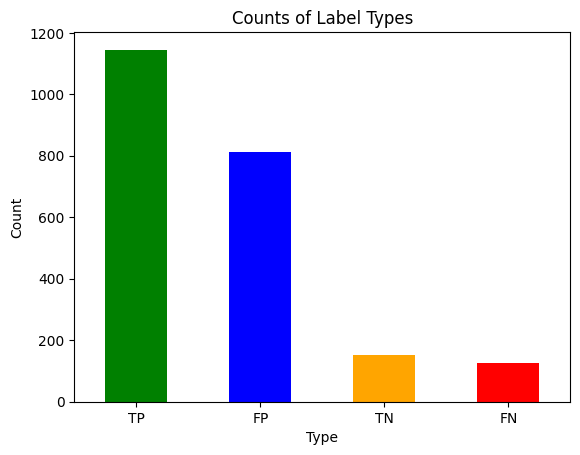

In [25]:

#########################
# 1)Post Augumentation: Distribution of labels
########################

counts = df["First_label"].value_counts() 
counts


counts.plot(kind="bar", color=["green", "blue", "orange", "red"])
plt.title("Counts of Label Types")
plt.xlabel("Type")
plt.ylabel("Count")
plt.xticks(rotation=0)  # Keep x-axis labels horizontal
plt.show()


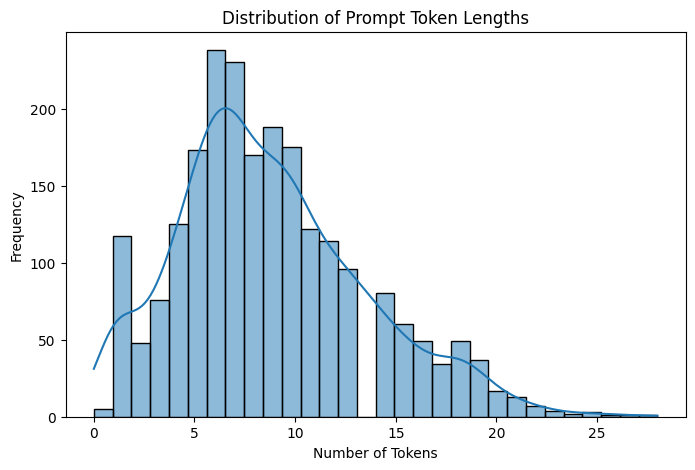

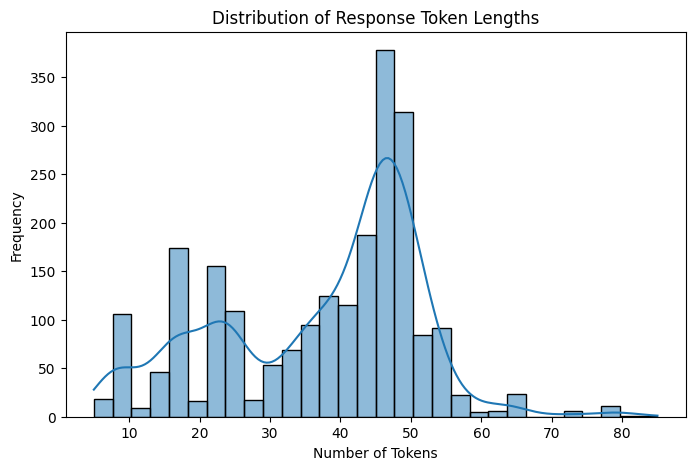

In [26]:

#########################
# 2)Prompt text length distribution
########################

# Add token length column
df['prompt_token_length'] = df['First_prompt_lemmas'].apply(len)

# Plot distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['prompt_token_length'], bins=30, kde=True)
plt.title('Distribution of Prompt Token Lengths')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.show()



#########################
# 3)Response text length distribution
########################


# Add token length column
df['response_token_length'] = df['First_response_lemmas'].apply(len)

# Plot distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['response_token_length'], bins=30, kde=True)
plt.title('Distribution of Response Token Lengths')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.show()



In [27]:

#########################
# 4)Vocabulary Size of Prompt
########################

# Flatten all tokens into one list
all_tokens = [token for tokens in df['First_prompt_lemmas'] for token in tokens]

# Count unique tokens
vocab = set(all_tokens)
print(f"Total Prompt Tokens: {len(all_tokens)}")
print(f"Unique Prompt Tokens (Vocabulary Size): {len(vocab)}")



#########################
# 4)Vocabulary Size of Response
########################

# Flatten all tokens into one list
all_tokens = [token for tokens in df['First_response_lemmas'] for token in tokens]

# Count unique tokens
vocab = set(all_tokens)
print(f"Total Response Tokens: {len(all_tokens)}")
print(f"Unique Response Tokens (Vocabulary Size): {len(vocab)}")


Total Prompt Tokens: 19634
Unique Prompt Tokens (Vocabulary Size): 1497
Total Response Tokens: 83424
Unique Response Tokens (Vocabulary Size): 1512


/tmp/ipykernel_363/2375237175.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bigrams, y=frequencies, palette='magma')


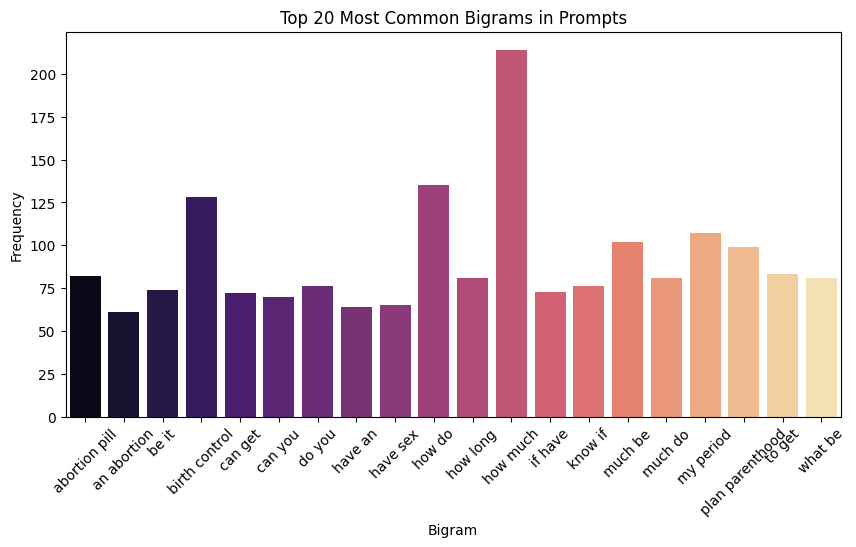

/tmp/ipykernel_363/2375237175.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bigrams, y=frequencies, palette='magma')


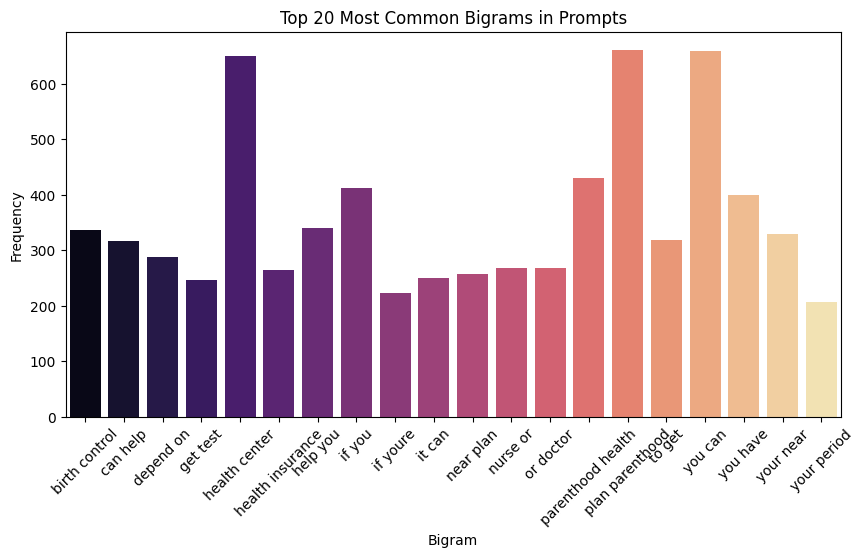

In [28]:
# Join lemmatized tokens back into strings
joined_texts = df['First_prompt_lemmas'].apply(lambda tokens: ' '.join(tokens))

# Count bigrams (2-word sequences)
vectorizer = CountVectorizer(ngram_range=(2, 2), max_features=20)
X = vectorizer.fit_transform(joined_texts)

# Get bigram names and frequencies
bigrams = vectorizer.get_feature_names_out()
frequencies = X.toarray().sum(axis=0)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=bigrams, y=frequencies, palette='magma')
plt.xticks(rotation=45)
plt.title('Top 20 Most Common Bigrams in Prompts')
plt.xlabel('Bigram')
plt.ylabel('Frequency')
plt.show()

# Join lemmatized tokens back into strings
joined_texts = df['First_response_lemmas'].apply(lambda tokens: ' '.join(tokens))

# Count bigrams (2-word sequences)
vectorizer = CountVectorizer(ngram_range=(2, 2), max_features=20)
X = vectorizer.fit_transform(joined_texts)

# Get bigram names and frequencies
bigrams = vectorizer.get_feature_names_out()
frequencies = X.toarray().sum(axis=0)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=bigrams, y=frequencies, palette='magma')
plt.xticks(rotation=45)
plt.title('Top 20 Most Common Bigrams in Prompts')
plt.xlabel('Bigram')
plt.ylabel('Frequency')
plt.show()


In [29]:
df[df["First_label"]=='FN'].head(32)

,Genesys_interaction_id,Full_conversation,First_prompt,First_response,First_label,Flag_label_for_review,Comment,Labeller,Reviewer_suggested_label,Reviewer_comment,First_prompt_clean,First_response_clean,First_label_clean,First_prompt_lemmas,First_response_lemmas,First_label_lemmas,First_prompt_final_features,prompt_token_length,response_token_length
438,37f3ad3c-714e-433b-9847-bce7bff89ac1,"[{""text"":""Hey there, I'm Roo! You can ask me q...",Heyy,Sometimes we bots have a hard time understandi...,FN,False,None,Michael,None,None,hey,sometimes we bots have a hard time understandi...,fn,[hey],"[sometimes, we, bot, have, a, hard, time, unde...",[fn],hey,1,17
439,8348acca-1cb5-4638-b48a-f6a78b1b5c71,"[{""text"":""Hey there, I'm Roo! You can ask me q...",hi,Sometimes we bots have a hard time understandi...,FN,False,None,Michael,None,None,hi,sometimes we bots have a hard time understandi...,fn,[hi],"[sometimes, we, bot, have, a, hard, time, unde...",[fn],hi,1,17
440,45047c46-7667-4069-b2db-279634f2dd58,"[{""text"":""Hey there, I'm Roo! You can ask me q...",How do I reschedule,Sometimes we bots have a hard time understandi...,FN,False,None,Michael,None,None,how do i reschedule,sometimes we bots have a hard time understandi...,fn,"[how, do, i, reschedule]","[sometimes, we, bot, have, a, hard, time, unde...",[fn],reschedule,4,17
443,71675712-5786-4d2c-9756-a689e9108965,"[{""text"":""Hey there, I'm Roo! You can ask me q...",hi,Sometimes we bots have a hard time understandi...,FN,False,None,Michael,None,None,hi,sometimes we bots have a hard time understandi...,fn,[hi],"[sometimes, we, bot, have, a, hard, time, unde...",[fn],hi,1,17
449,e159eb54-94d7-44e6-afea-dd3e15740ead,"[{""text"":""Hey there, I'm Roo! You can ask me q...",Hlo,Sometimes we bots have a hard time understandi...,FN,True,marginal,Michael,None,None,ho,sometimes we bots have a hard time understandi...,fn,[ho],"[sometimes, we, bot, have, a, hard, time, unde...",[fn],ho,1,17
450,8485ed35-e703-4b85-a2ea-6ca7cee69389,"[{""text"":""Hey there, I'm Roo! You can ask me q...",hi,Sometimes we bots have a hard time understandi...,FN,False,None,Michael,None,None,hi,sometimes we bots have a hard time understandi...,fn,[hi],"[sometimes, we, bot, have, a, hard, time, unde...",[fn],hi,1,17
451,a9392f5f-db7b-41b7-9108-6eb33d7647e4,"[{""text"":""Hey there, I'm Roo! You can ask me q...",Heyy,Sometimes we bots have a hard time understandi...,FN,False,None,Michael,None,None,hey,sometimes we bots have a hard time understandi...,fn,[hey],"[sometimes, we, bot, have, a, hard, time, unde...",[fn],hey,1,17
454,c313ed3b-0207-48b4-9f9b-fc3bff4bfebb,"[{""text"":""Hey there, I'm Roo! You can ask me q...",How soon do you catch molluscum,Sometimes we bots have a hard time understandi...,FN,False,None,Michael,None,None,how soon do you catch molluscs,sometimes we bots have a hard time understandi...,fn,"[how, soon, do, you, catch, mollusc]","[sometimes, we, bot, have, a, hard, time, unde...",[fn],soon catch mollusc,6,17
455,a814db11-a5ab-464d-8e87-7feb59669f89,"[{""text"":""Hey there, I'm Roo! You can ask me q...",How do I create an account so I can access my ...,Sometimes we bots have a hard time understandi...,FN,False,None,Michael,None,None,how do i create an account so i can access my ...,sometimes we bots have a hard time understandi...,fn,"[how, do, i, create, an, account, so, i, can, ...","[sometimes, we, bot, have, a, hard, time, unde...",[fn],create account access lab result,13,17
456,5e2121b2-76b8-43a2-9b9e-7a027903756c,"[{""text"":""Hey there, I'm Roo! You can ask me q...",hi,Sometimes we bots have a hard time understandi...,FN,False,None,Michael,None,None,hi,sometimes we bots have a hard time understandi...,fn,[hi],"[sometimes, we, bot, have, a, hard, time, unde...",[fn],hi,1,17


In [30]:
#7) Vectorization

In [31]:
df["First_prompt_lemmas_txt"] = df["First_prompt_lemmas"].apply(lambda x: " ".join(x) if isinstance(x, list) else "")

df["First_prompt_lemmas_txt"] = df["First_prompt_lemmas_txt"].fillna("")

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df["First_prompt_lemmas_txt"])

y = df["First_label_clean"]

# 6. Inspect the result
print("Feature names:", tfidf.get_feature_names_out()[:10])
print("TF-IDF vector (first 3 rows):", X.toarray()[:3])



Feature names: ['09' '10' '11' '1199' '12' '13' '14' '15' '16' '1621']
TF-IDF vector (first 3 rows): [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [32]:
#8)Train a Model: Logistic Regression (Base Model)

In [33]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.33, random_state=1234)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1497, 1475)
(738, 1475)
(1497,)
(738,)


In [34]:


model = LogisticRegression(max_iter=1000, random_state=1234)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)  # for log_loss or probability outputs

#Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Log Loss:", log_loss(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n Classification Report:\n", classification_report(y_test, y_pred))



Accuracy: 0.6585365853658537
Log Loss: 0.8152853384459839

Confusion Matrix:
 [[  3  19   0  26]
 [  0 161   0  98]
 [  0  33   1  19]
 [  0  57   0 321]]

 Classification Report:
               precision    recall  f1-score   support

          fn       1.00      0.06      0.12        48
          fp       0.60      0.62      0.61       259
          tn       1.00      0.02      0.04        53
          tp       0.69      0.85      0.76       378

    accuracy                           0.66       738
   macro avg       0.82      0.39      0.38       738
weighted avg       0.70      0.66      0.61       738



In [35]:
#Logistic Regression: Hyperparameter Tuning 

In [36]:
# Pipeline for sparse TF-IDF
pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("logreg", LogisticRegression(max_iter=20000, penalty="l2", solver="lbfgs"))
])

param_grid = {
    "logreg__C": [0.01, 0.1, 1, 10, 100],
    "logreg__class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=1   # important to avoid semlock crash
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Log Loss:", log_loss(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Best Parameters: {'logreg__C': 100, 'logreg__class_weight': 'balanced'}
Accuracy: 0.7100271002710027
Log Loss: 4.339343175169153

Confusion Matrix:
 [[ 21  11   1  15]
 [  3 178  14  64]
 [  6   6  25  16]
 [ 15  58   5 300]]

Classification Report:
               precision    recall  f1-score   support

          fn       0.47      0.44      0.45        48
          fp       0.70      0.69      0.70       259
          tn       0.56      0.47      0.51        53
          tp       0.76      0.79      0.78       378

    accuracy                           0.71       738
   macro avg       0.62      0.60      0.61       738
weighted avg       0.71      0.71      0.71       738



In [37]:
#Logistic Regression: Using BERT

In [38]:
# 1. Prepare text and labels
X_texts = df["First_prompt_lemmas_txt"].astype(str).tolist()
y = df["First_label_clean"]

# Train/test split (use raw text)
X_train_texts, X_test_texts, y_train, y_test = train_test_split(
    X_texts, y, test_size=0.2, random_state=42
)

# 2. Generate Sentence-BERT embeddings
print("Generating Sentence-BERT embeddings...")
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

X_train_sbert = sbert_model.encode(X_train_texts, batch_size=32, show_progress_bar=True)
X_test_sbert = sbert_model.encode(X_test_texts, batch_size=32, show_progress_bar=True)

print("Train embeddings shape:", X_train_sbert.shape)
print("Test embeddings shape:", X_test_sbert.shape)

# 3. Train Logistic Regression
pipe = Pipeline([
    ("scaler", StandardScaler()),   # embeddings are dense
    ("logreg", LogisticRegression(
        max_iter=5000, 
        penalty="l2", 
        solver="lbfgs", 
        class_weight="balanced"  # optional, for imbalanced classes
    ))
])

pipe.fit(X_train_sbert, y_train)


# 4. Predictions
y_pred = pipe.predict(X_test_sbert)
y_prob = pipe.predict_proba(X_test_sbert)

# 5. Evaluation
print("\n--- Logistic Regression on Sentence-BERT ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Log Loss:", log_loss(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Generating Sentence-BERT embeddings...


Batches:   0%|          | 0/56 [00:00<?, ?it/s]

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

Train embeddings shape: (1788, 384)
Test embeddings shape: (447, 384)

--- Logistic Regression on Sentence-BERT ---
Accuracy: 0.7472035794183445
Log Loss: 1.3371395693445673

Confusion Matrix:
 [[ 11   4   2   4]
 [  5 110   8  33]
 [  4   6  25   6]
 [  7  33   1 188]]

Classification Report:
               precision    recall  f1-score   support

          fn       0.41      0.52      0.46        21
          fp       0.72      0.71      0.71       156
          tn       0.69      0.61      0.65        41
          tp       0.81      0.82      0.82       229

    accuracy                           0.75       447
   macro avg       0.66      0.66      0.66       447
weighted avg       0.75      0.75      0.75       447



In [39]:
#9) Comparison Models(Decision Tree Classifier, Random Forest, Gradient Boosting) 

In [40]:
#Decision Tree Classifier (Comparison Model)

In [41]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2, random_state=42)

=== Decision Tree Performance (TF-IDF) ===
              precision    recall  f1-score   support

          fn      0.600     0.143     0.231        21
          fp      0.746     0.321     0.448       156
          tn      0.333     0.024     0.045        41
          tp      0.581     0.943     0.719       229

    accuracy                          0.604       447
   macro avg      0.565     0.358     0.361       447
weighted avg      0.617     0.604     0.540       447

Precision: 0.617
Recall:    0.604
F1-score:  0.540
Accuracy:  0.604


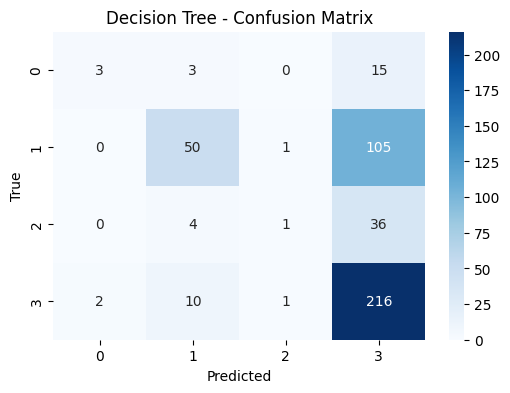

In [42]:
dt_clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    random_state=42
)
dt_clf.fit(X_train, y_train)

y_pred_dt = dt_clf.predict(X_test)

print("=== Decision Tree Performance (TF-IDF) ===")
print(classification_report(y_test, y_pred_dt, digits=3))

precision_dt = precision_score(y_test, y_pred_dt, average='weighted')
recall_dt    = recall_score(y_test, y_pred_dt, average='weighted')
f1_dt        = f1_score(y_test, y_pred_dt, average='weighted')
acc_dt       = accuracy_score(y_test, y_pred_dt)

print(f"Precision: {precision_dt:.3f}")
print(f"Recall:    {recall_dt:.3f}")
print(f"F1-score:  {f1_dt:.3f}")
print(f"Accuracy:  {acc_dt:.3f}")

cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [43]:
#Decision Tree Classifier: Hyperparameter Tuning 

Fitting 5 folds for each of 480 candidates, totalling 2400 fits


Traceback (most recent call last):
  File "/usr/local/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /tmp/joblib_memmapping_folder_363_9efc740ae8074c70bf4fd1de0c4eba43_10d69b1c87c349c3b226a5a058bc3079 for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-363-tyjokxta for automatic cleanup: unknown resource type semlock
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown res

Best hyperparameters: {'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
 Tuned Decision Tree Performance (TF-IDF) 
              precision    recall  f1-score   support

          fn      0.533     0.381     0.444        21
          fp      0.712     0.699     0.706       156
          tn      0.576     0.463     0.514        41
          tp      0.797     0.856     0.825       229

    accuracy                          0.743       447
   macro avg      0.655     0.600     0.622       447
weighted avg      0.735     0.743     0.737       447

Precision: 0.735
Recall:    0.743
F1-score:  0.737
Accuracy:  0.743


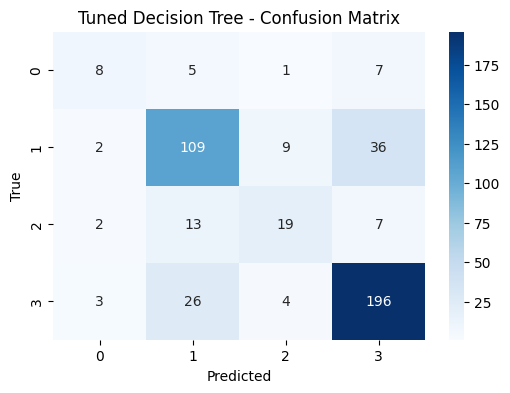

In [44]:
#  Hyperparameter Grid 
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 20, 30, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2'],
}

#  Grid Search 
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X_train, y_train)

print("Best hyperparameters:", grid_dt.best_params_)

#  Train Best Model 
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)

#  Evaluation 
print(" Tuned Decision Tree Performance (TF-IDF) ")
print(classification_report(y_test, y_pred_dt, digits=3))

precision_dt = precision_score(y_test, y_pred_dt, average='weighted')
recall_dt    = recall_score(y_test, y_pred_dt, average='weighted')
f1_dt        = f1_score(y_test, y_pred_dt, average='weighted')
acc_dt       = accuracy_score(y_test, y_pred_dt)

print(f"Precision: {precision_dt:.3f}")
print(f"Recall:    {recall_dt:.3f}")
print(f"F1-score:  {f1_dt:.3f}")
print(f"Accuracy:  {acc_dt:.3f}")

# ---------------- Confusion Matrix ----------------
cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Tuned Decision Tree - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [45]:
#Decision Tree Classifier: Using BERT

In [46]:
X_texts = df["First_prompt_lemmas_txt"].astype(str).tolist()
y = df["First_label_clean"]

# Train/test split (USE THE RAW TEXT)
X_train_texts, X_test_texts, y_train, y_test = train_test_split(
    X_texts, y, test_size=0.2, random_state=42
)

print("Generating Sentence-BERT embeddings...")
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

X_train_sbert = sbert_model.encode(
    X_train_texts, batch_size=32, convert_to_numpy=True, show_progress_bar=True
)
X_test_sbert = sbert_model.encode(
    X_test_texts, batch_size=32, convert_to_numpy=True, show_progress_bar=True
)

print("Train embeddings shape:", X_train_sbert.shape)
print("Test embeddings shape:", X_test_sbert.shape)

# Decision Tree Model 
dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=10,
    random_state=42
)

dt_model.fit(X_train_sbert, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test_sbert)
y_prob_dt = dt_model.predict_proba(X_test_sbert)

print("\n--- Decision Tree on Sentence-BERT ---")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Log Loss:", log_loss(y_test, y_prob_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))

Generating Sentence-BERT embeddings...


Batches:   0%|          | 0/56 [00:00<?, ?it/s]

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

Train embeddings shape: (1788, 384)
Test embeddings shape: (447, 384)

--- Decision Tree on Sentence-BERT ---
Accuracy: 0.7002237136465325
Log Loss: 6.903783744165367
Classification Report:
               precision    recall  f1-score   support

          fn       0.31      0.24      0.27        21
          fp       0.66      0.68      0.67       156
          tn       0.72      0.32      0.44        41
          tp       0.75      0.83      0.78       229

    accuracy                           0.70       447
   macro avg       0.61      0.51      0.54       447
weighted avg       0.69      0.70      0.69       447



In [47]:
#Random Forest (Comparison Model)

Random Forest Log Loss: 0.8387859695217664
Random Forest Accuracy: 0.8031319910514542
Random Forest Classification Report:
               precision    recall  f1-score   support

          fn       1.00      0.33      0.50        21
          fp       0.74      0.81      0.77       156
          tn       0.79      0.46      0.58        41
          tp       0.84      0.90      0.87       229

    accuracy                           0.80       447
   macro avg       0.84      0.63      0.68       447
weighted avg       0.81      0.80      0.79       447



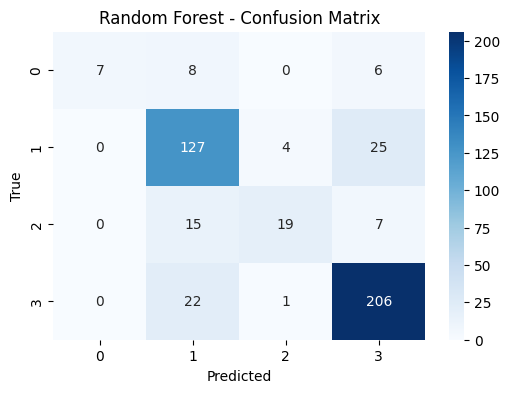

,Model,Precision,Recall,F1-Score,Accuracy
0,Logistic Regression,0.750687,0.747204,0.748320,0.747204
1,Random Forest,0.809800,0.803132,0.793605,0.803132


In [48]:
def train_test_RF(X_train, y_train, X_test, y_test, n_estimators=100, class_weight='balanced'):
    
    rf_model = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=42,
        class_weight=class_weight
    )
    
    # Train model
    rf_model.fit(X_train, y_train)
    
    # Predictions
    probability_predictions = rf_model.predict_proba(X_test)
    class_label_predictions = rf_model.predict(X_test)
    
    # Confusion matrix
    confu_matrix = confusion_matrix(y_test, class_label_predictions)
    
    # Metrics
    l_loss = log_loss(y_test, probability_predictions)
    acc_score = accuracy_score(y_test, class_label_predictions)
    
    precision_rf = precision_score(y_test, class_label_predictions, average='weighted')
    recall_rf    = recall_score(y_test, class_label_predictions, average='weighted')
    f1_rf        = f1_score(y_test, class_label_predictions, average='weighted')

    classif_report = classification_report(y_test, class_label_predictions)

    print("Random Forest Log Loss:", l_loss)
    print("Random Forest Accuracy:", acc_score)
    print("Random Forest Classification Report:\n", classif_report)
    
    return rf_model, l_loss, acc_score, confu_matrix, precision_rf, recall_rf, f1_rf

# Run RF model
rf_model, l_loss, acc_rf, confu_matrix, precision_rf, recall_rf, f1_rf = train_test_RF(
    X_train, y_train, X_test, y_test
)

#Confusion Matrix Display
plt.figure(figsize=(6,4))
sns.heatmap(confu_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()



# Logistic Regression metrics
precision_lr = precision_score(y_test, y_pred, average='weighted')
recall_lr    = recall_score(y_test, y_pred, average='weighted')
f1_lr        = f1_score(y_test, y_pred, average='weighted')
acc_lr       = accuracy_score(y_test, y_pred)


# Comparison table
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Precision': [precision_lr, precision_rf],
    'Recall': [recall_lr, recall_rf],
    'F1-Score': [f1_lr, f1_rf],
    'Accuracy': [acc_lr, acc_rf]
})

display(comparison)


In [49]:
#Random Forest: Hyperparameter Tuning 

In [50]:
#Train Random Forest with GridSearchCV and return best model
def train_test_RF_grid(X_train, y_train, X_test, y_test):
   
    # Base model
    rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

    # Hyperparameter grid
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt', 'log2']
    }

    # GridSearchCV
    grid_search = GridSearchCV(
        estimator=rf_model,
        param_grid=param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=1,  # safe for Python 3.13
        verbose=1
    )

    # Fit grid search
    grid_search.fit(X_train, y_train)

    # Best model
    best_rf = grid_search.best_estimator_
    print("Best Hyperparameters:", grid_search.best_params_)

    # Predictions
    y_pred = best_rf.predict(X_test)
    y_prob = best_rf.predict_proba(X_test)
    
    # Metrics
    confu_matrix = confusion_matrix(y_test, y_pred)
    l_loss = log_loss(y_test, y_prob)
    acc_score = accuracy_score(y_test, y_pred)
    precision_rf = precision_score(y_test, y_pred, average='weighted')
    recall_rf = recall_score(y_test, y_pred, average='weighted')
    f1_rf = f1_score(y_test, y_pred, average='weighted')
    classif_report = classification_report(y_test, y_pred)

    print("Random Forest Log Loss:", l_loss)
    print("Random Forest Accuracy:", acc_score)
    print("Random Forest Classification Report:\n", classif_report)

    # Confusion matrix plot
    plt.figure(figsize=(6,4))
    sns.heatmap(confu_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title('Random Forest (GridSearchCV) - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return best_rf, l_loss, acc_score, confu_matrix, precision_rf, recall_rf, f1_rf

In [51]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.33, random_state=1234)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


Traceback (most recent call last):
  File "/usr/local/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-363-r158w_ji for automatic cleanup: unknown resource type semlock
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-363-1ch6vksd for automatic cleanup: unknown resource type semlock
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-363-gla0yo83 for automati

Best Hyperparameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Random Forest Log Loss: 0.6500031634640222
Random Forest Accuracy: 0.7452574525745257
Random Forest Classification Report:
               precision    recall  f1-score   support

          fn       0.75      0.50      0.60        48
          fp       0.68      0.73      0.70       259
          tn       0.67      0.60      0.63        53
          tp       0.80      0.81      0.81       378

    accuracy                           0.75       738
   macro avg       0.72      0.66      0.69       738
weighted avg       0.75      0.75      0.74       738



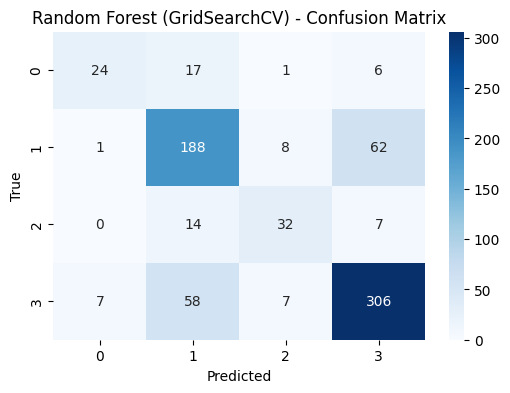

In [52]:
# Run
rf_model_tuned, l_loss, acc_rf, confu_matrix, precision_rf, recall_rf, f1_rf = train_test_RF_grid(
    X_train, y_train, X_test, y_test
)

In [53]:
#Random Forest: Using BERT

In [54]:

X_texts = df["First_prompt_lemmas_txt"].astype(str).tolist()
y = df["First_label_clean"]

# Train/test split 
X_train_texts, X_test_texts, y_train, y_test = train_test_split(
    X_texts, y, test_size=0.2, random_state=42
)

# Generate Sentence-BERT embeddings
print("Generating Sentence-BERT embeddings...")
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

X_train_sbert = sbert_model.encode(X_train_texts, batch_size=32, show_progress_bar=True)
X_test_sbert = sbert_model.encode(X_test_texts, batch_size=32, show_progress_bar=True)

print("Train embeddings shape:", X_train_sbert.shape)
print("Test embeddings shape:", X_test_sbert.shape)

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    n_jobs=-1,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train_sbert, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test_sbert)
y_prob_rf = rf_model.predict_proba(X_test_sbert)

print("\n--- Random Forest on Sentence-BERT ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Log Loss:", log_loss(y_test, y_prob_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))





Generating Sentence-BERT embeddings...


Batches:   0%|          | 0/56 [00:00<?, ?it/s]

Traceback (most recent call last):
  File "/usr/local/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-363-p0yz1vqm for automatic cleanup: unknown resource type semlock


Batches:   0%|          | 0/14 [00:00<?, ?it/s]

Traceback (most recent call last):
  File "/usr/local/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-363-_bw9saiu for automatic cleanup: unknown resource type semlock


Train embeddings shape: (1788, 384)
Test embeddings shape: (447, 384)

--- Random Forest on Sentence-BERT ---
Accuracy: 0.767337807606264
Log Loss: 0.5316294943202953
Classification Report:
               precision    recall  f1-score   support

          fn       0.67      0.38      0.48        21
          fp       0.81      0.69      0.75       156
          tn       1.00      0.32      0.48        41
          tp       0.74      0.93      0.83       229

    accuracy                           0.77       447
   macro avg       0.80      0.58      0.63       447
weighted avg       0.79      0.77      0.75       447



In [55]:
#Gradient Boosting (Comparison Model)

In [56]:
if 'First_prompt_lemmas_txt' not in df.columns:
    # Fallback: Create a simple cleaned text column if the lemma one doesn't exist
    print("Creating text features...")
    df['First_prompt_lemmas_txt'] = df['First_prompt'].fillna('').astype(str).str.lower()
    
# 2. Ensure we have the target labels
y_target = df['First_label_clean'] if 'First_label_clean' in df.columns else df['First_label']

# 3. TF-IDF Vectorization (Creating X)
print("Vectorizing data with TF-IDF...")
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['First_prompt_lemmas_txt'])
y = y_target

# 4. Train-Test Split (Creating X_train, X_test...)
print("Splitting data into Train and Test sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=1234, stratify=y
)

print(f"Success! X_train shape: {X_train.shape}")
print(f"You can now run the Gradient Boosting cell.")

Vectorizing data with TF-IDF...
Splitting data into Train and Test sets...
Success! X_train shape: (1497, 1475)
You can now run the Gradient Boosting cell.


Gradient Boosting Log Loss: 0.7774473375118091
Gradient Boosting Accuracy: 0.7046070460704607
Gradient Boosting Classification Report:
               precision    recall  f1-score   support

          fn       0.86      0.29      0.43        42
          fp       0.62      0.69      0.65       268
          tn       0.67      0.24      0.35        50
          tp       0.76      0.82      0.79       378

    accuracy                           0.70       738
   macro avg       0.73      0.51      0.56       738
weighted avg       0.71      0.70      0.69       738



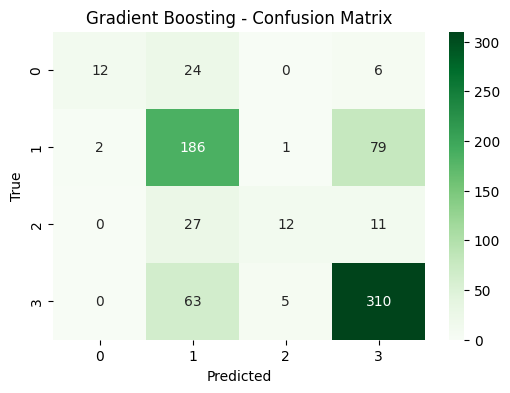

,Model,Precision,Recall,F1-Score,Accuracy
0,Logistic Regression,0.750687,0.747204,0.748320,0.747204
1,Random Forest,0.746216,0.745257,0.743714,0.745257
2,Gradient Boosting,0.710182,0.704607,0.691188,0.704607


In [58]:
def train_test_GB(X_train, y_train, X_test, y_test, n_estimators=150, learning_rate=0.1):
    
    gb_model = GradientBoostingClassifier(
        n_estimators=n_estimators,
        random_state=42,
        learning_rate=learning_rate
    )
    
    # Train model
    gb_model.fit(X_train, y_train)
    
    # Predictions
    probability_predictions = gb_model.predict_proba(X_test)
    class_label_predictions = gb_model.predict(X_test)
    
    # Confusion matrix
    confu_matrix = confusion_matrix(y_test, class_label_predictions)
    
    # Metrics
    l_loss = log_loss(y_test, probability_predictions)
    acc_score = accuracy_score(y_test, class_label_predictions)
    
    precision_gb = precision_score(y_test, class_label_predictions, average='weighted')
    recall_gb    = recall_score(y_test, class_label_predictions, average='weighted')
    f1_gb        = f1_score(y_test, class_label_predictions, average='weighted')

    classif_report = classification_report(y_test, class_label_predictions)

    print("Gradient Boosting Log Loss:", l_loss)
    print("Gradient Boosting Accuracy:", acc_score)
    print("Gradient Boosting Classification Report:\n", classif_report)
    
    return gb_model, l_loss, acc_score, confu_matrix, precision_gb, recall_gb, f1_gb

# Run GB model
gb_model, l_loss_gb, acc_gb, cm_gb, precision_gb, recall_gb, f1_gb = train_test_GB(
    X_train, y_train, X_test, y_test
)

# Confusion Matrix Display
plt.figure(figsize=(6,4))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Greens')
plt.title('Gradient Boosting - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# --- Comparison Table Update ---

# Comparison table (Adding Gradient Boosting)
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Precision': [precision_lr, precision_rf, precision_gb],
    'Recall': [recall_lr, recall_rf, recall_gb],
    'F1-Score': [f1_lr, f1_rf, f1_gb],
    'Accuracy': [acc_lr, acc_rf, acc_gb]
})

display(comparison)

In [59]:
#Gradient Boosting: Hyperparameter Tuning 

Starting Hyperparameter Tuning for Gradient Boosting...
Fitting 3 folds for each of 12 candidates, totalling 36 fits


Traceback (most recent call last):
  File "/usr/local/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /tmp/joblib_memmapping_folder_363_4f4e9995c00c481f8c20f89ab50d7573_9977999625f346c2a59b57db3bfcf45d for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /tmp/joblib_memmapping_folder_363_9efc740ae8074c70bf4fd1de0c4eba43_214603b67e534fd8bbab45d7017acafe for automatic cleanup: unknown resource type folder


[CV] END ..learning_rate=0.05, max_depth=3, n_estimators=100; total time=   2.6s
[CV] END ..learning_rate=0.05, max_depth=3, n_estimators=100; total time=   2.8s
[CV] END ..learning_rate=0.05, max_depth=3, n_estimators=100; total time=   2.9s
[CV] END ..learning_rate=0.05, max_depth=5, n_estimators=100; total time=   4.0s
[CV] END ..learning_rate=0.05, max_depth=5, n_estimators=100; total time=   4.3s
[CV] END ..learning_rate=0.05, max_depth=3, n_estimators=200; total time=   5.3s
[CV] END ..learning_rate=0.05, max_depth=3, n_estimators=200; total time=   5.4s
[CV] END ..learning_rate=0.05, max_depth=3, n_estimators=200; total time=   5.7s
[CV] END ..learning_rate=0.05, max_depth=5, n_estimators=100; total time=   4.2s
[CV] END ..learning_rate=0.05, max_depth=7, n_estimators=100; total time=   8.1s
[CV] END ..learning_rate=0.05, max_depth=7, n_estimators=100; total time=   8.5s
[CV] END ..learning_rate=0.05, max_depth=7, n_estimators=100; total time=   8.5s
[CV] END ..learning_rate=0.0

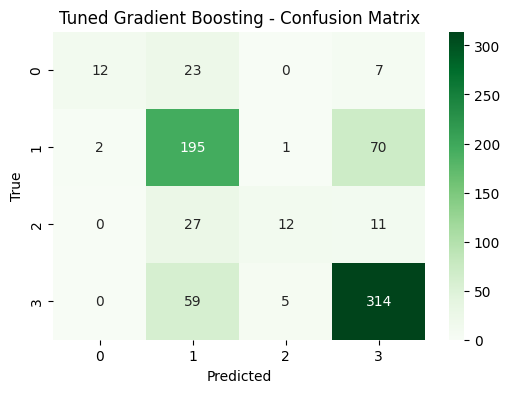

Tuned model saved to 'gradient_boosting_tfidf_tuned.joblib'


In [61]:
import joblib
# --- Gradient Boosting Hyperparameter Tuning ---
print("Starting Hyperparameter Tuning for Gradient Boosting...")

# 1. Define the Parameter Grid
# These are the settings we will test to find the best combination
param_grid = {
    'n_estimators': [100, 200],      # Number of boosting stages
    'max_depth': [3, 5, 7],          # Maximum depth of individual estimators
    'learning_rate': [0.05, 0.1]     # Step size shrinkage
}

# 2. Initialize the Base Model
gb_base = GradientBoostingClassifier(random_state=42)

# 3. Setup GridSearchCV
# cv=3 means 3-fold Cross-Validation
grid_search = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,  # Use all available CPU cores
    verbose=2   # Print progress
)

# 4. Fit the Search
grid_search.fit(X_train, y_train)

# 5. Retrieve Best Results
best_gb_model = grid_search.best_estimator_
print("\nBest Parameters Found:", grid_search.best_params_)

# 6. Evaluate Best Model
y_pred_tuned = best_gb_model.predict(X_test)
y_prob_tuned = best_gb_model.predict_proba(X_test)

l_loss_tuned = log_loss(y_test, y_prob_tuned)
acc_tuned = accuracy_score(y_test, y_pred_tuned)

print("\n--- Tuned Gradient Boosting Performance ---")
print("Log Loss:", l_loss_tuned)
print("Accuracy:", acc_tuned)
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned))

# 7. Confusion Matrix for Best Model
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6,4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens')
plt.title('Tuned Gradient Boosting - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 8. Save the Best Model
joblib.dump(best_gb_model, 'gradient_boosting_tfidf_tuned.joblib')
print("Tuned model saved to 'gradient_boosting_tfidf_tuned.joblib'")

In [62]:
#Gradient Boosting: Using BERT

Splitting text data...
Generating S-BERT embeddings (this may take a moment)...


Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Batches:   0%|          | 0/24 [00:00<?, ?it/s]


Training Gradient Boosting on BERT embeddings...

=== Gradient Boosting (S-BERT) Performance ===
Accuracy: 0.7575
Log Loss: 0.6250

Classification Report:
               precision    recall  f1-score   support

          fn       0.52      0.31      0.39        42
          fp       0.72      0.75      0.73       268
          tn       0.71      0.40      0.51        50
          tp       0.80      0.86      0.83       378

    accuracy                           0.76       738
   macro avg       0.69      0.58      0.62       738
weighted avg       0.75      0.76      0.75       738



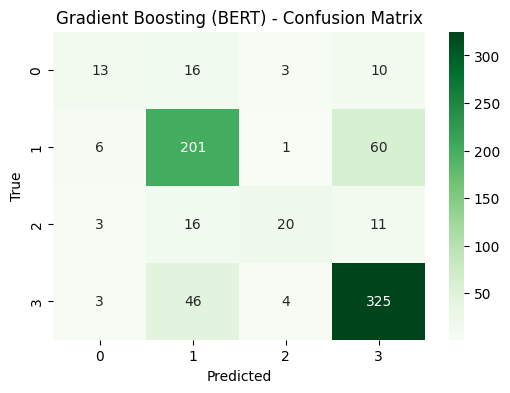

In [63]:
# --- 1. Prepare Text Data for BERT ---
# We need raw text for BERT, not the TF-IDF vectors we used before.
# We use the same random_state (1234) to ensure the rows match your other splits.
print("Splitting text data...")
X_txt_train, X_txt_test, y_bert_train, y_bert_test = train_test_split(
    df['First_prompt_lemmas_txt'],
    df['First_label_clean'],
    test_size=0.33,
    random_state=1234,
    stratify=df['First_label_clean']
)

# --- 2. Generate Embeddings (S-BERT) ---
print("Generating S-BERT embeddings (this may take a moment)...")
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

# Encode training and test sets
X_train_bert = sbert_model.encode(X_txt_train.tolist(), show_progress_bar=True)
X_test_bert = sbert_model.encode(X_txt_test.tolist(), show_progress_bar=True)

# --- 3. Train Gradient Boosting on Embeddings ---
print("\nTraining Gradient Boosting on BERT embeddings...")
gb_bert = GradientBoostingClassifier(
    n_estimators=150, 
    learning_rate=0.1, 
    random_state=42
)
gb_bert.fit(X_train_bert, y_bert_train)

# --- 4. Evaluate ---
y_pred_bert = gb_bert.predict(X_test_bert)
y_prob_bert = gb_bert.predict_proba(X_test_bert)

# Calculate Metrics
acc_bert = accuracy_score(y_bert_test, y_pred_bert)
l_loss_bert = log_loss(y_bert_test, y_prob_bert)

print(f"\n=== Gradient Boosting (S-BERT) Performance ===")
print(f"Accuracy: {acc_bert:.4f}")
print(f"Log Loss: {l_loss_bert:.4f}")
print("\nClassification Report:\n", classification_report(y_bert_test, y_pred_bert))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_bert_test, y_pred_bert), annot=True, fmt='d', cmap='Greens')
plt.title('Gradient Boosting (BERT) - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()